### Setup Libraries

In [1]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Set display settings so all columns are visible when viewing a df instead of truncated
pd.set_option("display.max_columns", None)

### Import data (download dataset from Kaggle to tmp folder)

In [3]:
# Download datasets
import os

os.system("Kaggle datasets download -d zusmani/paradisepanamapapers -p /tmp/paradise --unzip")

Dataset URL: https://www.kaggle.com/datasets/zusmani/paradisepanamapapers
License(s): CC-BY-SA-3.0


100%|██████████| 134M/134M [00:10<00:00, 14.0MB/s] 


0

In [4]:
# import os

# Only download if files are not already in /tmp/paradise
if not os.path.exists('/tmp/paradise/all_edges.csv'):
    os.system('kaggle datasets download -d zusmani/paradisepanamapapers -p /tmp/paradise --unzip')
    print("Download complete")
else:
    print("Files already exist, skipping download")

Files already exist, skipping download


### Load datasets

In [5]:
# Load the combined files into df
addresses = pd.read_csv("/tmp/paradise/Addresses.csv", low_memory = False)
entities = pd.read_csv("/tmp/paradise/Entities.csv", low_memory = False)
intermediaries = pd.read_csv("/tmp/paradise/Intermediaries.csv", low_memory = False)
officers = pd.read_csv("/tmp/paradise/Officers.csv", low_memory = False)
edges = pd.read_csv("/tmp/paradise/all_edges.csv", low_memory = False)

### EDA

In [6]:
# Quick look of each dataframe
for name, df in [('addresses', addresses), ('entities', entities), ('intermediaries', intermediaries), ('officers', officers), ('edges', edges)]:
    print(f'\n{name}: {df.shape}')
    print(df.columns.tolist())


addresses: (151605, 8)
['address', 'icij_id', 'valid_until', 'country_codes', 'countries', 'node_id', 'sourceID', 'note']

entities: (495038, 21)
['name', 'original_name', 'former_name', 'jurisdiction', 'jurisdiction_description', 'company_type', 'address', 'internal_id', 'incorporation_date', 'inactivation_date', 'struck_off_date', 'dorm_date', 'status', 'service_provider', 'ibcRUC', 'country_codes', 'countries', 'note', 'valid_until', 'node_id', 'sourceID']

intermediaries: (24177, 10)
['name', 'internal_id', 'address', 'valid_until', 'country_codes', 'countries', 'status', 'node_id', 'sourceID', 'note']

officers: (370854, 8)
['name', 'icij_id', 'valid_until', 'country_codes', 'countries', 'node_id', 'sourceID', 'note']

edges: (1535552, 7)
['node_1', 'rel_type', 'node_2', 'sourceID', 'valid_until', 'start_date', 'end_date']


*Analysis*
- entities has the most features - jurisdiction, incorporation date, status, service provider, all good for analysis
- intermediaries is tiny (24k) but will be the most connected nodes in the graph - these are the key players
- edges has rel_type - that's the relationship type between nodes, good to know what values are in there
- sourceID appears in all files - which leak the record comes from (Panama, Paradise, etc.)

In [7]:
# Preview each dataframe
for name, df in [('addresses', addresses), ('entities', entities), ('intermediaries', intermediaries), ('officers', officers), ('edges', edges)]:
    print(f'{name}')
    display(df.head(3))
    print(df.info())

addresses


,address,icij_id,valid_until,country_codes,countries,node_id,sourceID,note
0,-\t27 ROSEWOOD DRIVE #16-19 SINGAPORE 737920,6991059DFFB057DF310B9BF31CC4A0E6,The Panama Papers data is current through 2015,SGP,Singapore,14000001,Panama Papers,NaN
1,"""Almaly Village"" v.5, Almaty Kazakhstan",C65A269424AA1A8BBAC416FA30150938,The Panama Papers data is current through 2015,KAZ,Kazakhstan,14000002,Panama Papers,NaN
2,"""Cantonia"" South Road St Georges Hill Weybridg...",240EE44DFB70AF775E6CD02AF8CB889B,The Panama Papers data is current through 2015,GBR,United Kingdom,14000003,Panama Papers,NaN


<class 'pandas.DataFrame'>
RangeIndex: 151605 entries, 0 to 151604
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype
---  ------         --------------   -----
 0   address        151604 non-null  str  
 1   icij_id        93982 non-null   str  
 2   valid_until    151605 non-null  str  
 3   country_codes  150714 non-null  str  
 4   countries      150714 non-null  str  
 5   node_id        151605 non-null  int64
 6   sourceID       151605 non-null  str  
 7   note           23 non-null      str  
dtypes: int64(1), str(7)
memory usage: 9.3 MB
None
entities


,name,original_name,former_name,jurisdiction,jurisdiction_description,company_type,address,internal_id,incorporation_date,inactivation_date,struck_off_date,dorm_date,status,service_provider,ibcRUC,country_codes,countries,note,valid_until,node_id,sourceID
0,"TIANSHENG INDUSTRY AND TRADING CO., LTD.","TIANSHENG INDUSTRY AND TRADING CO., LTD.",NaN,SAM,Samoa,NaN,ORION HOUSE SERVICES (HK) LIMITED ROOM 1401; 1...,1001256.0,23-MAR-2006,18-FEB-2013,15-FEB-2013,NaN,Defaulted,Mossack Fonseca,25221,HKG,Hong Kong,NaN,The Panama Papers data is current through 2015,10000001,Panama Papers
1,"NINGBO SUNRISE ENTERPRISES UNITED CO., LTD.","NINGBO SUNRISE ENTERPRISES UNITED CO., LTD.",NaN,SAM,Samoa,NaN,ORION HOUSE SERVICES (HK) LIMITED ROOM 1401; 1...,1001263.0,27-MAR-2006,27-FEB-2014,15-FEB-2014,NaN,Defaulted,Mossack Fonseca,25249,HKG,Hong Kong,NaN,The Panama Papers data is current through 2015,10000002,Panama Papers
2,"HOTFOCUS CO., LTD.","HOTFOCUS CO., LTD.",NaN,SAM,Samoa,NaN,ORION HOUSE SERVICES (HK) LIMITED ROOM 1401; 1...,1000896.0,10-JAN-2006,15-FEB-2012,15-FEB-2012,NaN,Defaulted,Mossack Fonseca,24138,HKG,Hong Kong,NaN,The Panama Papers data is current through 2015,10000003,Panama Papers


<class 'pandas.DataFrame'>
RangeIndex: 495038 entries, 0 to 495037
Data columns (total 21 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   name                      495034 non-null  str    
 1   original_name             389522 non-null  str    
 2   former_name               6726 non-null    str    
 3   jurisdiction              495038 non-null  str    
 4   jurisdiction_description  495038 non-null  str    
 5   company_type              103227 non-null  str    
 6   address                   299319 non-null  str    
 7   internal_id               389522 non-null  float64
 8   incorporation_date        485607 non-null  str    
 9   inactivation_date         144760 non-null  str    
 10  struck_off_date           272240 non-null  str    
 11  dorm_date                 20207 non-null   str    
 12  status                    310106 non-null  str    
 13  service_provider          319150 non-null  str    
 14 

...

<class 'pandas.DataFrame'>
RangeIndex: 24177 entries, 0 to 24176
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   name           24176 non-null  str  
 1   internal_id    14651 non-null  str  
 2   address        8643 non-null   str  
 3   valid_until    24177 non-null  str  
 4   country_codes  22663 non-null  str  
 5   countries      22663 non-null  str  
 6   status         12621 non-null  str  
 7   node_id        24177 non-null  int64
 8   sourceID       24177 non-null  str  
 9   note           6 non-null      str  
dtypes: int64(1), str(9)
memory usage: 1.8 MB
None
officers


,name,icij_id,valid_until,country_codes,countries,node_id,sourceID,note
0,KIM SOO IN,E72326DEA50F1A9C2876E112AAEB42BC,The Panama Papers data is current through 2015,KOR,South Korea,12000001,Panama Papers,NaN
1,Tian Yuan,58287E0FD37852000D9D5AB8B27A2581,The Panama Papers data is current through 2015,CHN,China,12000002,Panama Papers,NaN
2,GREGORY JOHN SOLOMON,F476011509FD5C2EF98E9B1D74913CCE,The Panama Papers data is current through 2015,AUS,Australia,12000003,Panama Papers,NaN


<class 'pandas.DataFrame'>
RangeIndex: 370854 entries, 0 to 370853
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype
---  ------         --------------   -----
 0   name           370792 non-null  str  
 1   icij_id        238402 non-null  str  
 2   valid_until    370854 non-null  str  
 3   country_codes  252056 non-null  str  
 4   countries      252056 non-null  str  
 5   node_id        370854 non-null  int64
 6   sourceID       370854 non-null  str  
 7   note           132 non-null     str  
dtypes: int64(1), str(7)
memory usage: 22.6 MB
None
edges


,node_1,rel_type,node_2,sourceID,valid_until,start_date,end_date
0,11000001,intermediary of,10208879,Panama Papers,The Panama Papers data is current through 2015,NaN,NaN
1,11000001,intermediary of,10198662,Panama Papers,The Panama Papers data is current through 2015,NaN,NaN
2,11000001,intermediary of,10159927,Panama Papers,The Panama Papers data is current through 2015,NaN,NaN


<class 'pandas.DataFrame'>
RangeIndex: 1535552 entries, 0 to 1535551
Data columns (total 7 columns):
 #   Column       Non-Null Count    Dtype
---  ------       --------------    -----
 0   node_1       1535552 non-null  int64
 1   rel_type     1535552 non-null  str  
 2   node_2       1535552 non-null  int64
 3   sourceID     1484685 non-null  str  
 4   valid_until  1479375 non-null  str  
 5   start_date   554575 non-null   str  
 6   end_date     113798 non-null   str  
dtypes: int64(2), str(5)
memory usage: 82.0 MB
None


In [8]:
# What types of relationships exist?
print("Relationship types:")
print(edges['rel_type'].value_counts())

# Which leaks are represented?
print("\nLeak sources in entities:")
print(entities['sourceID'].value_counts())

Relationship types:
rel_type
intermediary of                        494997
shareholder of                         399358
registered address                     317027
director of                            118589
similar name and address as             46761
                                        ...  
director / chief investment officer         1
director, vice president                    1
director, secretary, president              1
director, secretary, vice president         1
Nominee Investment Advisor of               1
Name: count, Length: 287, dtype: int64

Leak sources in entities:
sourceID
Panama Papers     213634
Bahamas Leaks     175888
Offshore Leaks    105516
Name: count, dtype: int64


In [9]:
# Check sourceID across all files
for name, df in [('entities', entities), ('officers', officers), 
                  ('intermediaries', intermediaries), ('addresses', addresses),
                  ('edges', edges)]:
    print(f"\n{name} sourceID:")
    print(df['sourceID'].value_counts())


entities sourceID:
sourceID
Panama Papers     213634
Bahamas Leaks     175888
Offshore Leaks    105516
Name: count, dtype: int64

officers sourceID:
sourceID
Panama Papers     238402
Offshore Leaks    107190
Bahamas Leaks      25262
Name: count, dtype: int64

intermediaries sourceID:
sourceID
Panama Papers     14110
Offshore Leaks     9526
Bahamas Leaks       541
Name: count, dtype: int64

addresses sourceID:
sourceID
Panama Papers     93454
Offshore Leaks    57600
Bahamas Leaks       551
Name: count, dtype: int64

edges sourceID:
sourceID
Panama Papers     674102
Offshore Leaks    561393
Bahamas Leaks     249190
Name: count, dtype: int64


<!-- ### Note on data
Despite the dataset being named paradisepanamapapers, the Paradise Papers are not present in this version. 
The dataset contains Panama Papers, Offshore Leaks, and Bahamas Leaks only. -->

In [10]:
# Check missing data in all dataframes
for name, df in [('addresses', addresses), ('entities', entities),
                 ('intermediaries', intermediaries), ('officers', officers), 
                 ('edges', edges)]:
    print(f'\n{name} null cases and rates (%):')
    null_df = pd.DataFrame({
        'null_count':  df.isnull().sum(),
        'null_rate %':(df.isnull().sum() / len(df) * 100).round(1)
    })
    
    print(null_df)
    



addresses null cases and rates (%):
               null_count  null_rate %
address                 1          0.0
icij_id             57623         38.0
valid_until             0          0.0
country_codes         891          0.6
countries             891          0.6
node_id                 0          0.0
sourceID                0          0.0
note               151582        100.0

entities null cases and rates (%):
                          null_count  null_rate %
name                               4          0.0
original_name                 105516         21.3
former_name                   488312         98.6
jurisdiction                       0          0.0
jurisdiction_description           0          0.0
company_type                  391811         79.1
address                       195719         39.5
internal_id                   105516         21.3
incorporation_date              9431          1.9
inactivation_date             350278         70.8
struck_off_date           

*Analysis*
- note column is 100% null across almost every file. Useless information so can be dropped.
- edges is the cleanest file. node_1, rel_type, and node_2 are all 100% complete, matters for building the graph.
- start_date (64% null) and end_date (93% null) in edges. Most relationships have no time information.
- entities has very high nulls in company_type (79%), dorm_date (96%), former_name (99%). Messy data in real world.
- country_codes and countries are always null together because they represent the same information. One is shorter code and one as full name, so if a country is unknown, then both will be missing.

In [11]:
# Drop columns with too many nulls, > 95% nulls - not informative for data analysis
entities.drop(columns=['note', 'former_name', 'dorm_date'], inplace=True)
addresses.drop(columns=['note'], inplace=True)
intermediaries.drop(columns=['note'], inplace=True)
officers.drop(columns=['note'], inplace=True)

print("Dropped columns with >95% nulls - no analytic value")

Dropped columns with >95% nulls - no analytic value


In [13]:
# Check data shape to confirm drop
for name, df in[('entities', entities), ('addresses', addresses),
                ('officers', officers), ('intermediaries', intermediaries)]:
    print(f"{name}:{df.shape}")

entities:(495038, 18)
addresses:(151605, 7)
officers:(370854, 7)
intermediaries:(24177, 9)


### What to think about FinCrime intelligence for EDA:
- Who - who are the officers, intermediaries, and entities appear most frequently? High frequency can be a red flag. An intermediaries connected to many entities is suspicious.
- Where - which jurisdictions are most used? Certain countries are known tax havens and concentrations in these countries can be suspicious.
- Connection - which nodes sit between the most others? 
- When - dates for incorporation and inactivation and activities around these dates can give clues to the legitimacy of the entities.
- What types of relationship in the edges - reveal clues about ownership.

### Where are most of the offshore entities set up (where offshore companies or trust registered)?
- Tell us the preferred tax haven or jurisdiction

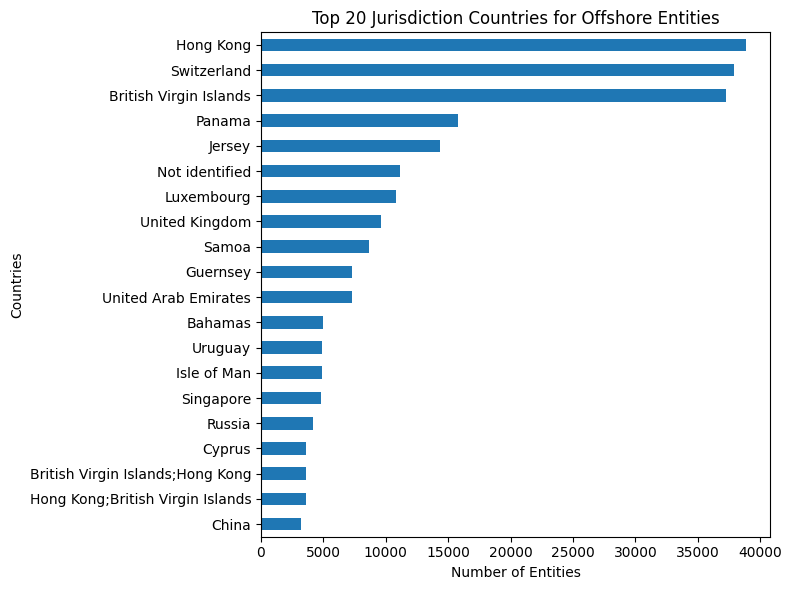

In [24]:
# Count how many entities registered in each country and take top 20 in descending
top_countries = entities['countries'].value_counts().head(20).sort_values(ascending=True)

# Plot bar chart
top_countries.plot(kind = 'barh', figsize=(8, 6))
plt.title('Top 20 Jurisdiction Countries for Offshore Entities')
plt.ylabel('Countries')
plt.xlabel('Number of Entities')
plt.tight_layout()
plt.show()

*Analysis*
- HK and Switzerland topped the list ahead of the classic tax havens like British Virgin Island, Panama and Jersey. HK is unexpected but make sense since it's a gateway for the wealthy Chinese/Asians into the offshore system.
- Countries like British Virgin Islands, Panama, Jersey, Guernsey, Isle of Man are expected to be in the top list. All are well known tax havens.
- 'Not identified' has significant entities - these are red flag since they are unknown.
- The two bottom countries on the list have dual jurisdicition, which can complicate entities resolution.

### Who are the most active enablers (intermediaries)?
- Intermediaries are the law firms and agents who set up the offshore companies to make these companies appears legal.
- High frequency intermediaries is red flag, and who are they connected to the most.

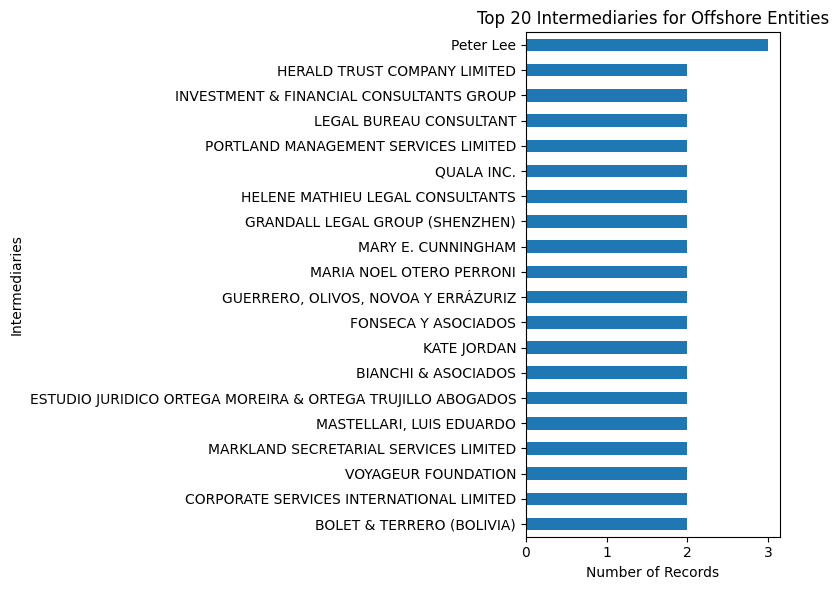

In [ ]:
# Count the top 20 most frequent intermediaries.
top_intermediaries = intermediaries['name'].value_counts().head(20).sort_values(ascending=True)

# Plot bar chart
top_intermediaries.plot(kind = 'barh', figsize=(8, 6))
plt.title('Top 20 Intermediaries for Offshore Entities')
plt.ylabel('Intermediaries')
plt.xlabel('Number of Records')
plt.tight_layout()
plt.show()

*Analysis*
- Almost all intermediaries in the top 20 only show up 2-3x max.
- Counting the intermediaries names from its data table only shows the duplicate entries but it doesn't give the number of entities they are connected to.
- Here is a limitation in this type of data analysis where it cannot reveal the true measure of intermediary activity, which is the number of edges - explore this in graph notebook.

### When - find out if there is any pattern in the offshore entities incorporation time

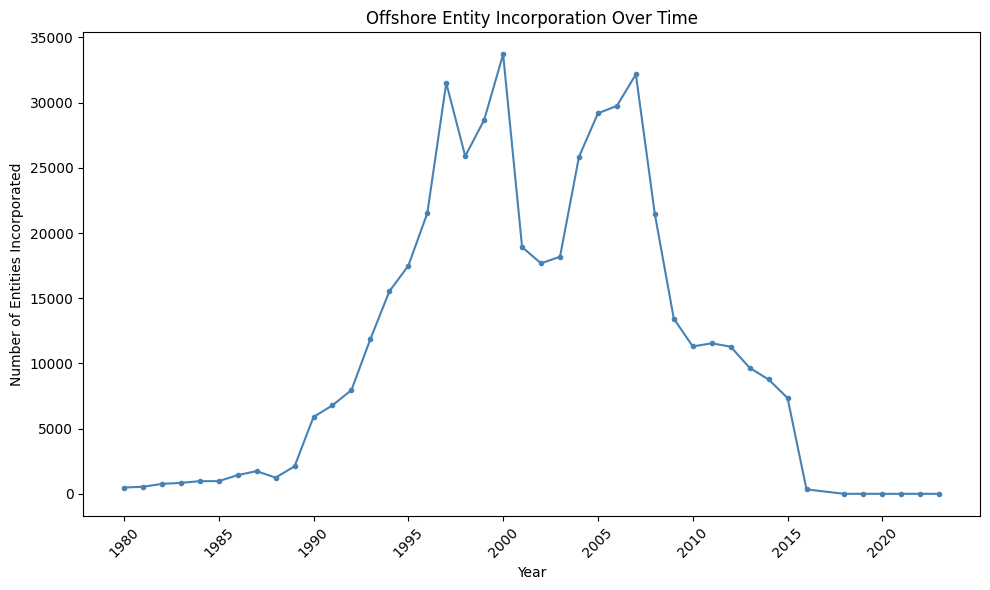

In [49]:
# Convert entities 'incorporation_date' column to datetime format so we can plot it over time
entities['incorporation_date'] = pd.to_datetime(entities['incorporation_date'], errors='coerce')

# Extract the year from the date
entities['incorporation_year'] = entities['incorporation_date'].dt.year

# Count incorporation of entities per year
incorporation_per_year = entities['incorporation_year'].value_counts().sort_index()
incorporation_per_year = incorporation_per_year[incorporation_per_year.index >= 1980]

# Plot entities incorporation over the years using line plot (for count & trends)
incorporation_per_year.plot(kind = 'line', figsize=(10, 6), color = 'steelblue', marker = 'o', markersize = 3)
plt.title('Offshore Entity Incorporation Over Time')
plt.xlabel('Year')
plt.ylabel('Number of Entities Incorporated')
# plt.xticks(range(1920, 2025, 5), rotation = 45) # every 5years
plt.xticks(range(1980, 2025, 5), rotation = 45) # every 5years
plt.tight_layout()
plt.show()

*Analysis*
- There is a boom of incorporation between 1985-2015 suggesting offshore industry grow massively during these years. What are the factors contributing to this in the finance industry? Likely include financial globalisation, deregulation, and the rise of complex corporate structures.
- Sharp drop in 2000 - a quick search on google tells me due to dot-com crash eliminated the financial demand for setting up new investment companies and international regulatory crackdown offshore companies that are untaxed. 
- There is a recovery period after year 2000 followed by another sharp drop in 2008, which is global financial crisis. 
- Sharp decline after 2015 is certainly due to the global regulatory crackdown and Pananam paper leak itself in 2016, where beneficial companies ownership registers were introduced, reducing anonymity for offshore entities.

### What are the types of relationship between entities, officers and intermediaries?
- This tell us about how the offshore entities are controlled and owned.

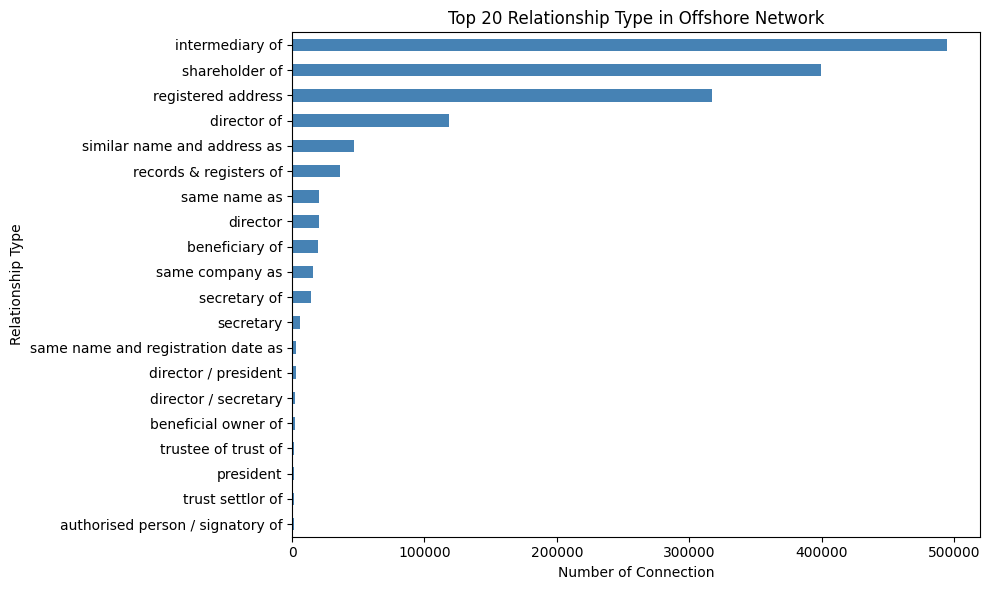

In [52]:
# Count the top 15 relationship types
top_rel_type = edges['rel_type'].value_counts().head(20).sort_values(ascending=True)

# Plot bar chart
top_rel_type.plot(kind='barh', figsize=(10, 6), color='steelblue')
plt.title('Top 20 Relationship Type in Offshore Network')
plt.xlabel('Number of Connection')
plt.ylabel('Relationship Type')
plt.tight_layout()
plt.show()


*Analysis*
- 'Intermediary of' topped the list! Confirming agents and law firms are the main part in the offshore system.
- 'Shareholder and registered address' and 'director of' show the owners are next most common, which make sense for corporate system.
- 'Similar names and address as' and 'same name as' are red flags for entity resolutions. Are these duplicates entities?
- Some relationship type have low counts - are these data reliable or inconsistency?

### Final summary

This EDA explores the ICIJ Offshore Leaks dataset covering Panama Papers, Bahamas Leaks, 
and Offshore Leaks (note: Paradise Papers are absent despite the dataset name).

Key findings:
- Hong Kong, Switzerland, and British Virgin Islands are the top jurisdictions for offshore entities.
- Offshore incorporations boomed between 1985-2015, with dips in 2000 (dot-com crash) and 2008 (financial crisis), followed by sharp decline after the Panama Papers leak in 2016.
- Intermediary activity cannot be meaningfully measured from the intermediaries table alone. True connectivity requires graph analysis (notebook 2).
- `intermediary of` and `shareholder of` are the dominant relationship types in the network.
- Significant data quality issues: high null rates, inconsistent country entries, and free text relationship labels.

The next step is to build a knowledge graph from these entities and relationships to reveal connections invisible in a flat table.